# STgram-MFN: Anomalous Sound Detection
**Spectral-Temporal Fusion with MobileFaceNet + ArcFace + GMM Scoring**

| Step | Description |
|------|-------------|
| 1 | Load raw audio + compute Mel spectrogram + Tgram features |
| 2 | Train STgram-MFN with ArcFace angular margin loss |
| 3 | Extract 128-dim features from trained model |
| 4 | Fit Gaussian Mixture Model on normal training features |
| 5 | Score test audio using negative GMM log-likelihood |
| 6 | Compare AUC-ROC against Autoencoder baseline |

In [8]:
!pip install -q torch torchaudio librosa scikit-learn matplotlib tqdm joblib

import os, sys
from google.colab import drive
drive.mount('/content/drive')

%cd /content
!git clone https://github.com/SarvagyaGupta-19/AutoEncoder-Based-Anomoly-Detection-.git project 2>/dev/null; true
%cd project
!git pull origin master

os.makedirs('data', exist_ok=True)
!rm -rf data/raw_audio
!ln -s /content/drive/MyDrive/data/raw_audio data/raw_audio
!ls data/raw_audio/

sys.path.insert(0, '.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
/content/project
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 357 bytes | 357.00 KiB/s, done.
From https://github.com/SarvagyaGupta-19/AutoEncoder-Based-Anomoly-Detection-
 * branch            master     -> FETCH_HEAD
   4d9b193..9ab0f09  master     -> origin/master
Updating 4d9b193..9ab0f09
Fast-forward
 stgram_train.ipynb | 8 ++++----
 1 file changed, 4 insertions(+), 4 deletions(-)
source_test  target_test  train


In [9]:
import re
import glob
import numpy as np
import torch
import torch.nn as nn
import torchaudio
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib

import config
from src.stgram_model import STgramMFN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Dataset & Label Extraction

In [10]:
class Wave2Mel:
    def __init__(self, sr=16000, n_fft=1024, n_mels=128,
                 win_length=1024, hop_length=512, power=2.0):
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr, win_length=win_length, hop_length=hop_length,
            n_fft=n_fft, n_mels=n_mels, power=power)
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(stype='power')

    def __call__(self, x):
        return self.amplitude_to_db(self.mel_transform(x))


def extract_labels(file_list):
    ids = sorted(set(
        re.findall(r'section_\d+', f)[0]
        for f in file_list if re.findall(r'section_\d+', f)
    ))
    return {id_str: i for i, id_str in enumerate(ids)}


class ASDDataset(Dataset):
    def __init__(self, file_list, meta2label, sr=16000, duration=10):
        self.file_list = file_list
        self.meta2label = meta2label
        self.sr = sr
        self.duration = duration
        self.wav2mel = Wave2Mel(sr=sr)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath = self.file_list[idx]
        id_str = re.findall(r'section_\d+', fpath)[0]
        label = self.meta2label[id_str]
        x, _ = librosa.load(fpath, sr=self.sr, mono=True)
        target_len = self.sr * self.duration
        if len(x) < target_len:
            x = np.pad(x, (0, target_len - len(x)))
        else:
            x = x[:target_len]
        x_wav = torch.from_numpy(x).float()
        x_mel = self.wav2mel(x_wav)
        return x_wav, x_mel, label

In [15]:
train_files = sorted(glob.glob(os.path.join(config.RAW_TRAIN_DIR, '*.wav')))
source_test_files = sorted(glob.glob(os.path.join(config.RAW_SOURCE_TEST_DIR, '*.wav')))
target_test_files = sorted(glob.glob(os.path.join(config.RAW_TARGET_TEST_DIR, '*.wav')))

meta2label = extract_labels(train_files)
num_classes = len(meta2label)

print(f'Training files:     {len(train_files)}')
print(f'Source test files:   {len(source_test_files)}')
print(f'Target test files:   {len(target_test_files)}')
print(f'\nLabel Mapping ({num_classes} classes):')
for k, v in meta2label.items():
    print(f'  {k} -> {v}')

train_dataset = ASDDataset(train_files, meta2label,
                           sr=config.SAMPLE_RATE, duration=config.AUDIO_DURATION)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True,drop_last=True)

Training files:     3009
Source test files:   600
Target test files:   603

Label Mapping (3 classes):
  section_00 -> 0
  section_01 -> 1
  section_02 -> 2


## Data Visualization

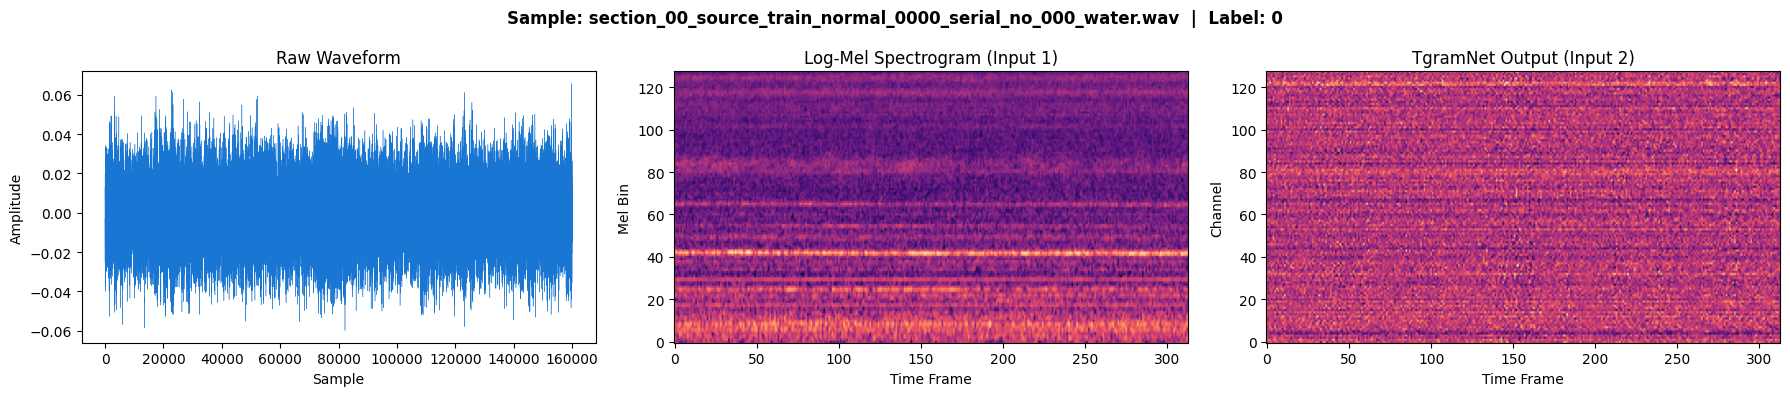

In [16]:
x_wav, x_mel, label = train_dataset[0]

viz_model = STgramMFN(num_classes=num_classes).eval()
with torch.no_grad():
    tgram = viz_model.tgramnet(x_wav.unsqueeze(0).unsqueeze(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].set_title('Raw Waveform')
axes[0].plot(x_wav.numpy(), linewidth=0.3, color='#1976D2')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')

axes[1].set_title('Log-Mel Spectrogram (Input 1)')
axes[1].imshow(x_mel.squeeze().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_xlabel('Time Frame')
axes[1].set_ylabel('Mel Bin')

axes[2].set_title('TgramNet Output (Input 2)')
axes[2].imshow(tgram.squeeze().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[2].set_xlabel('Time Frame')
axes[2].set_ylabel('Channel')

plt.suptitle(f'Sample: {os.path.basename(train_files[0])}  |  Label: {label}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stgram_sample_viz.png', dpi=150, bbox_inches='tight')
plt.show()
del viz_model

## Model Architecture

In [17]:
NUM_FRAMES = (config.SAMPLE_RATE * config.AUDIO_DURATION) // 512 + 1

model = STgramMFN(
    num_classes=num_classes,
    c_dim=config.N_MELS,
    win_len=1024,
    hop_len=512,
    n_mels=config.N_MELS,
    num_frames=NUM_FRAMES,
    use_arcface=True,
    m=0.5,
    s=30,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Num classes: {num_classes}')
print(f'Num frames: {NUM_FRAMES}')
print(model)

Total parameters: 1,151,513
Num classes: 3
Num frames: 313
STgramMFN(
  (arcface): ArcMarginProduct()
  (tgramnet): TgramNet(
    (conv_extractor): Conv1d(1, 128, kernel_size=(1024,), stride=(512,), padding=(512,), bias=False)
    (conv_encoder): Sequential(
      (0): Sequential(
        (0): LayerNorm((313,), eps=1e-05, elementwise_affine=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      )
      (1): Sequential(
        (0): LayerNorm((313,), eps=1e-05, elementwise_affine=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      )
      (2): Sequential(
        (0): LayerNorm((313,), eps=1e-05, elementwise_affine=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      )
    )
  )
  (mo

## Training

In [19]:
EPOCHS = 100
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for x_wav, x_mel, labels in pbar:
        x_wav = x_wav.float().to(device)
        x_mel = x_mel.float().to(device)
        labels = labels.long().to(device)

        logits, _ = model(x_wav, x_mel, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch 10/100: 100%|██████████| 94/94 [00:28<00:00,  3.28it/s, loss=0.0005]


Epoch 10 | Loss: 0.0502 | LR: 0.000361


Epoch 20/100: 100%|██████████| 94/94 [00:28<00:00,  3.32it/s, loss=0.0000]


Epoch 20 | Loss: 0.0047 | LR: 0.000219


Epoch 30/100: 100%|██████████| 94/94 [00:28<00:00,  3.30it/s, loss=0.0000]


...

Epoch 80 | Loss: 0.0085 | LR: 0.000194


Epoch 90/100: 100%|██████████| 94/94 [00:28<00:00,  3.29it/s, loss=0.0047]


Epoch 90 | Loss: 0.0598 | LR: 0.000331


Epoch 100/100: 100%|██████████| 94/94 [00:27<00:00,  3.37it/s, loss=0.0004]

Epoch 100 | Loss: 0.1290 | LR: 0.000484


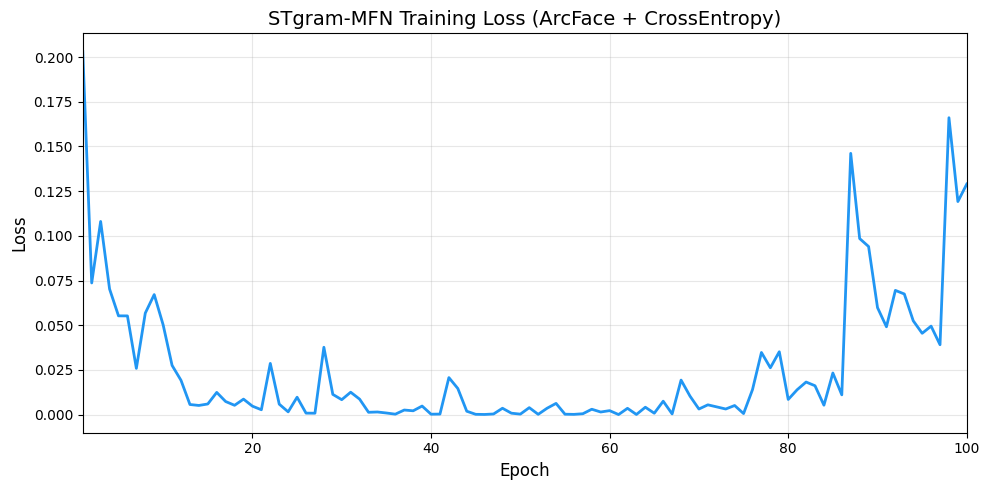

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(losses)+1), losses, linewidth=2, color='#2196F3')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('STgram-MFN Training Loss (ArcFace + CrossEntropy)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(losses))
plt.tight_layout()
plt.savefig('stgram_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Extraction & GMM Fitting

In [29]:
import torch.nn.functional as F

model.eval()
train_features_per_section = {}

with torch.no_grad():
    for x_wav, x_mel, labels in tqdm(train_loader, desc='Extracting features'):
        x_wav = x_wav.float().to(device)
        x_mel = x_mel.float().to(device)
        labels = labels.long().to(device)
        _, features = model(x_wav, x_mel, labels)
        features = F.normalize(features, dim=1)
        for feat, lbl in zip(features.cpu().numpy(), labels.cpu().numpy()):
            train_features_per_section.setdefault(int(lbl), []).append(feat)

gmm_per_section = {}
for lbl, feats in train_features_per_section.items():
    feats = np.array(feats)
    gmm_per_section[lbl] = GaussianMixture(n_components=2, covariance_type='full', reg_covar=1e-3)
    gmm_per_section[lbl].fit(feats)
    print(f'Section {lbl}: {feats.shape[0]} samples, GMM fitted')

train_features = np.concatenate(list(train_features_per_section.values()))
train_labels_arr = np.concatenate([[k]*len(v) for k, v in train_features_per_section.items()])


Extracting features: 100%|██████████| 94/94 [00:32<00:00,  2.89it/s]


Section 1: 1003 samples, GMM fitted
Section 2: 1003 samples, GMM fitted
Section 0: 1002 samples, GMM fitted


## t-SNE Feature Space Visualization

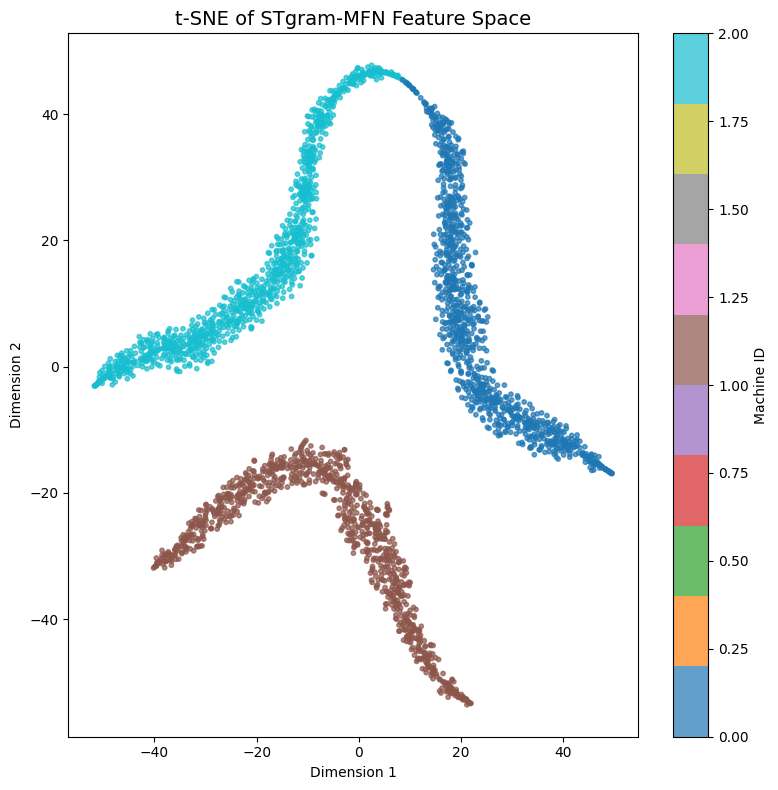

In [30]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(train_features)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1],
                     c=train_labels_arr, cmap='tab10', s=10, alpha=0.7)
ax.set_title('t-SNE of STgram-MFN Feature Space', fontsize=14)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
cbar = plt.colorbar(scatter)
cbar.set_label('Machine ID')
plt.tight_layout()
plt.savefig('stgram_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly Scoring & AUC-ROC

In [36]:
wav2mel = Wave2Mel(sr=config.SAMPLE_RATE)

def score_files(file_list):
    y_true, y_scores = [], []
    for fpath in tqdm(file_list, desc='Scoring'):
        fname = os.path.basename(fpath).lower()
        if 'normal' in fname:
            y_true.append(0)
        elif 'anomaly' in fname:
            y_true.append(1)
        else:
            continue

        id_str = re.findall(r'section_\d+', fpath)[0]
        label = meta2label[id_str]

        x, _ = librosa.load(fpath, sr=config.SAMPLE_RATE, mono=True)
        target_len = config.SAMPLE_RATE * config.AUDIO_DURATION
        if len(x) < target_len:
            x = np.pad(x, (0, target_len - len(x)))
        else:
            x = x[:target_len]

        x_wav = torch.from_numpy(x).float()
        x_mel = wav2mel(x_wav)
        x_wav = x_wav.unsqueeze(0).to(device)
        x_mel = x_mel.unsqueeze(0).to(device)
        label_t = torch.tensor([label]).long().to(device)

        with torch.no_grad():
            _, feature = model(x_wav, x_mel, label_t)
            feature = F.normalize(feature, dim=1)

        score = -np.max(gmm_per_section[label]._estimate_log_prob(feature.cpu().numpy()))
        y_scores.append(score)

    return np.array(y_true), np.array(y_scores)
y_true_src, y_scores_src = score_files(source_test_files)
y_true_tgt, y_scores_tgt = score_files(target_test_files)

auc_src = roc_auc_score(y_true_src, y_scores_src)
auc_tgt = roc_auc_score(y_true_tgt, y_scores_tgt)

print(f'Source Test AUC: {auc_src:.4f}')
print(f'Target Test AUC: {auc_tgt:.4f}')



Scoring: 100%|██████████| 603/603 [00:07<00:00, 78.51it/s]

Source Test AUC: 0.7105
Target Test AUC: 0.5767


## Evaluation Visualizations

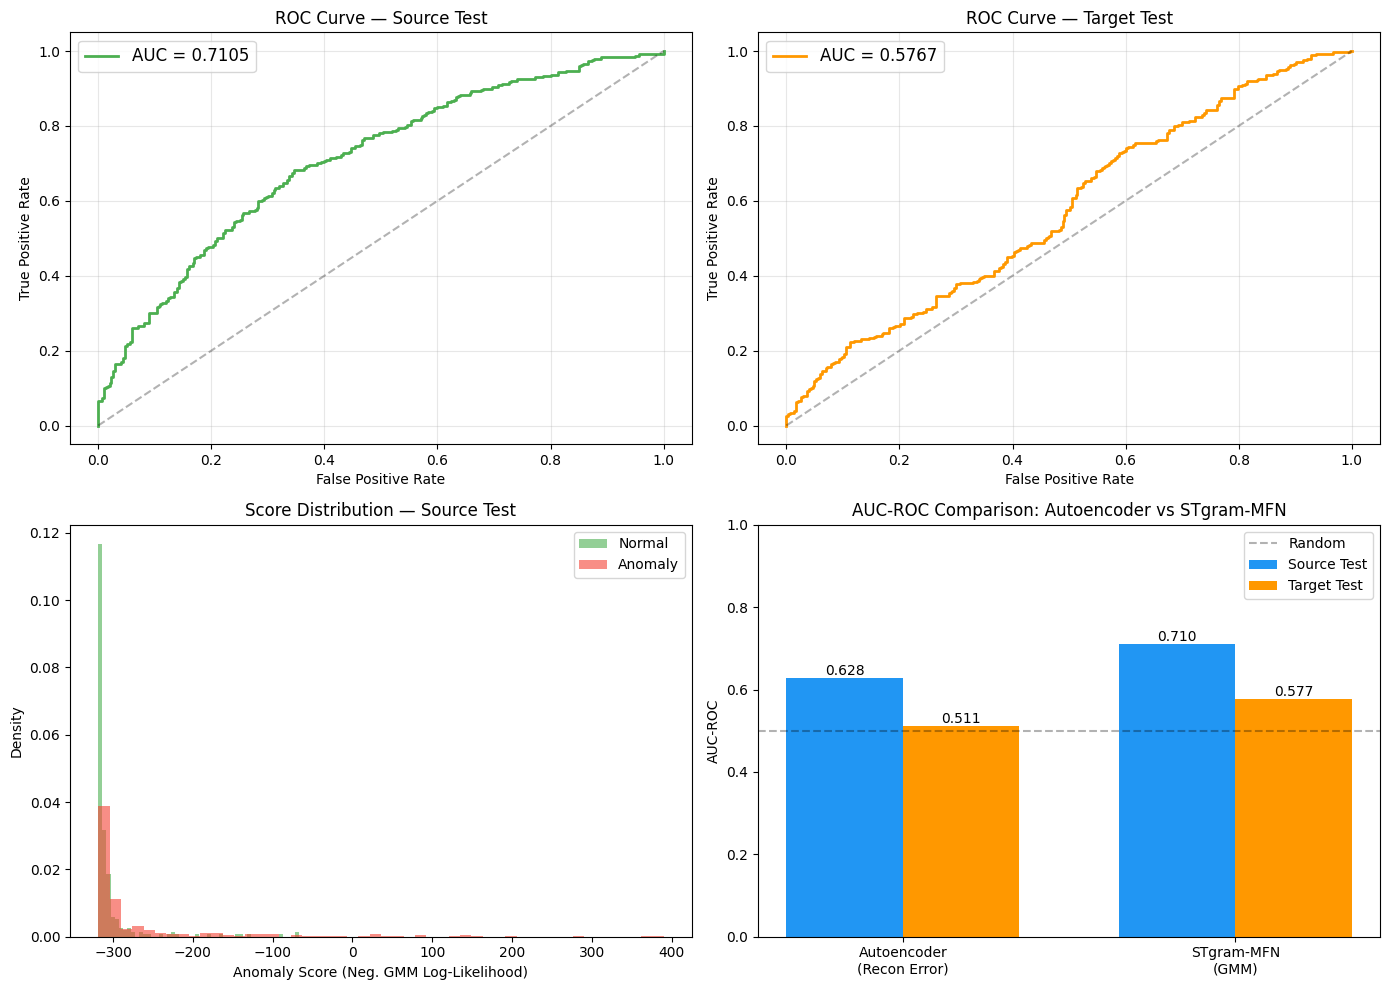

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr_src, tpr_src, _ = roc_curve(y_true_src, y_scores_src)
axes[0, 0].plot(fpr_src, tpr_src, linewidth=2, color='#4CAF50',
                label=f'AUC = {auc_src:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 0].set_title('ROC Curve — Source Test')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

fpr_tgt, tpr_tgt, _ = roc_curve(y_true_tgt, y_scores_tgt)
axes[0, 1].plot(fpr_tgt, tpr_tgt, linewidth=2, color='#FF9800',
                label=f'AUC = {auc_tgt:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_title('ROC Curve — Target Test')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

norm_src = y_scores_src[y_true_src == 0]
anom_src = y_scores_src[y_true_src == 1]
axes[1, 0].hist(norm_src, bins=50, alpha=0.6, color='#4CAF50',
                label='Normal', density=True)
axes[1, 0].hist(anom_src, bins=50, alpha=0.6, color='#F44336',
                label='Anomaly', density=True)
axes[1, 0].set_title('Score Distribution — Source Test')
axes[1, 0].set_xlabel('Anomaly Score (Neg. GMM Log-Likelihood)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

methods = ['Autoencoder\n(Recon Error)', 'STgram-MFN\n(GMM)']
src_aucs = [0.6281, auc_src]
tgt_aucs = [0.5111, auc_tgt]
x_pos = np.arange(len(methods))
width = 0.35
bars1 = axes[1, 1].bar(x_pos - width/2, src_aucs, width,
                       label='Source Test', color='#2196F3')
bars2 = axes[1, 1].bar(x_pos + width/2, tgt_aucs, width,
                       label='Target Test', color='#FF9800')
axes[1, 1].set_title('AUC-ROC Comparison: Autoencoder vs STgram-MFN')
axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(methods)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axhline(y=0.5, color='k', linestyle='--', alpha=0.3, label='Random')
axes[1, 1].legend()
axes[1, 1].bar_label(bars1, fmt='%.3f')
axes[1, 1].bar_label(bars2, fmt='%.3f')

plt.tight_layout()
plt.savefig('stgram_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Model & GMM

In [39]:
os.makedirs(config.MODEL_DIR, exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'meta2label': meta2label,
    'num_frames': NUM_FRAMES,
    'losses': losses,
    'auc_source': auc_src,
    'auc_target': auc_tgt,
}, config.STGRAM_MODEL_PATH)

joblib.dump(gmm, config.STGRAM_GMM_PATH)

print(f'Model saved:  {config.STGRAM_MODEL_PATH}')
print(f'GMM saved:    {config.STGRAM_GMM_PATH}')
print(f'\nFinal AUC-ROC:')
print(f'  Source: {auc_src:.4f}')
print(f'  Target: {auc_tgt:.4f}')

Model saved:  /content/project/models/stgram_mfn.pth
GMM saved:    /content/project/models/stgram_gmm.joblib

Final AUC-ROC:
  Source: 0.7105
  Target: 0.5767
